In [26]:
from data_extractor import DataExtractor

## 1) Carga de datos desde la API de Twitter

In [2]:
import os

file_path = "data/tweets_from_api.csv"

if os.path.exists(file_path):
    extractor = DataExtractor(file_path)
    df_api = extractor.load_data()
else:
    extractor = DataExtractor()
    df_api = extractor.load_data_api(
        query="bitcoin",
        api_calls=10,
        output_file=file_path
    )

df_api.head()

,tweet_id,user_name,date,text,lang,favorites,retweets,replies,views
0,2056097848060469374,0xChiefy,Sun May 17 19:41:42 +0000 2026,"Bitcoin is now in the $78,000–$82,000 resistan...",en,619,89,106,101988.0
1,2056465485848359206,0xChiefy,Mon May 18 20:02:33 +0000 2026,Bitcoin just entered the most dangerous phase ...,en,185,39,40,18770.0
2,2056706881586974748,Danny_Crypton,Tue May 19 12:01:46 +0000 2026,🚨 BITCOIN IS BOUNCING OFF TRENDLINE SUPPORT!!\...,en,100,19,30,8956.0
3,2056256859963904135,AndreaCapellin4,Mon May 18 06:13:33 +0000 2026,$BTC i am genuinely surprised watching scared...,en,30,1,9,7846.0
4,2056134371497644157,Bitcoinprof0637,Sun May 17 22:06:49 +0000 2026,🚨 BITCOIN IS NOW OVERSOLD WHILE GOLD LOOKS EXT...,en,702,146,100,74540.0


## 2) Limpieza y normalización de texto

In [3]:
for i, row in df_api.iterrows():
    text_test = row.get("text", "")
    cleaned_text = extractor.clean_text(text_test)
    print(f"{i}. Original: {text_test}\nLimpio: {cleaned_text}\n")
    if i >= 9:  # Limitar a las primeras 10 filas para evitar demasiada salida
        break

0. Original: Bitcoin is now in the $78,000–$82,000 resistance zone.

Most traders still think this is the start of a new bull run.

But next week, resistance will flip into bearish support, and $BTC will dump back to $60,000.

I perfectly predicted the Bitcoin bottom in 2022 and the top in 2025.

The same cycle structure is forming again in 2026.

Follow now and turn notifications on before it’s too late.
Limpio: bitcoin is now in the 7800082000 resistance zone most traders still think this is the start of a new bull run but next week resistance will flip into bearish support and btc will dump back to 60000 i perfectly predicted the bitcoin bottom in 2022 and the top in 2025 the same cycle structure is forming again in 2026 follow now and turn notifications on before its too late

1. Original: Bitcoin just entered the most dangerous phase of the cycle!

Everyone thinks it’s just another small correction before a new bull run.

And that’s exactly how retail is getting trapped.

The real

## 3) Análisis básico - Extracción de hashtags

In [4]:
for i, row in df_api.iterrows():
    text_test = row.get("text", "")
    text_hashtags = extractor.extract_hashtags(text_test)
    print(f"{i}. Texto: {text_test}\nHashtags: {text_hashtags}\n")
    if i > 9:  # Limitar a las primeras 10 filas para evitar demasiada salida
        break

0. Texto: Bitcoin is now in the $78,000–$82,000 resistance zone.

Most traders still think this is the start of a new bull run.

But next week, resistance will flip into bearish support, and $BTC will dump back to $60,000.

I perfectly predicted the Bitcoin bottom in 2022 and the top in 2025.

The same cycle structure is forming again in 2026.

Follow now and turn notifications on before it’s too late.
Hashtags: []

1. Texto: Bitcoin just entered the most dangerous phase of the cycle!

Everyone thinks it’s just another small correction before a new bull run.

And that’s exactly how retail is getting trapped.

The real pain starts when everyone feels safe.

The bull trap to $82K is over, and now $BTC will test new lows.

I called the exact Bitcoin bottom in 2022 and the exact top in 2025.

Now the same setup is appearing again in 2026.

Turn notifications on now - the next call will be posted here first.
Hashtags: []

2. Texto: 🚨 BITCOIN IS BOUNCING OFF TRENDLINE SUPPORT!!

This 100% ha

In [5]:
hashtag_analysis = extractor.analytics_hashtags_extended()

In [6]:
hashtag_analysis['overall'].head()

,hashtag,frequency
0,#bitcoin,27
1,#crypto,4
2,#btc,3
3,#binancepizza,2
4,#xrp,1


In [7]:
hashtag_analysis['by_user'].head()

,user_name,hashtag,frequency
0,BTCtreasuries,#bitcoin,1
1,BiconomyCom,#bitcoinpizzaday,1
2,BiconomyCom,#btc,1
3,BiconomyCom,#crypto,1
4,BitbullTrading,#bitcoin,1


In [8]:
hashtag_analysis['by_date'].head()

,date,hashtag,frequency
0,2026-05-07,#bitcoin,1
1,2026-05-12,#bitcoin,1
2,2026-05-14,#btc80k,1
3,2026-05-14,#fiatcollapse,1
4,2026-05-14,#goldrally,1


In [9]:
hashtag_analysis['keywords_overall'].head(20)

,keyword,frequency
0,bitcoin,212
1,btc,86
2,you,74
3,just,66
4,it,65
5,at,65
6,i,49
7,every,47
8,will,46
9,are,45


### Análisis de hashtags en datos provenientes de la API

Al aplicar el análisis de hashtags sobre el dataset obtenido mediante la API de Twitter (RapidAPI), se observa que las tablas resultantes aparecen vacías. Esto se debe a una característica del propio dataset y no a un error en la implementación.

En concreto, los tweets recuperados desde la API no contienen hashtags explícitos (es decir, términos precedidos por el símbolo `#`) dentro del campo de texto ni en los metadatos proporcionados (`entities.hashtags` aparece vacío en la mayoría de los casos). Por tanto, el método de extracción de hashtags no encuentra elementos que analizar.

Esto implica que:
- El pipeline de extracción de hashtags funciona correctamente.
- La ausencia de resultados se debe a la naturaleza de los datos obtenidos desde la API.
- Este comportamiento es coherente con el contenido real de los tweets analizados.

Como alternativa, en este tipo de datasets resulta más útil trabajar con:
- **keywords** extraídas del texto,
- análisis de sentimiento,
- modelado de tópicos (LDA),
- y resumen del contenido.

En conclusión, aunque el análisis de hashtags es relevante para datasets como el de la Unidad 2, en este caso concreto su utilidad es limitada debido a la falta de hashtags en los datos proporcionados por la API.

## 4) Modelado y análisis de sentimiento

In [10]:
lda_results = extractor.model_topics(num_topics=4, passes=10)

topics = lda_results["topics"]
lda_model = lda_results["lda_model"]
corpus_bow = lda_results["corpus_bow"]
dictionary = lda_results["dictionary"]

Tópico #0: ['die', 'xrp', 'etf', 'million', 'und']
Tópico #1: ['btc', 'years', 'coming', 'day', 'biggest']
Tópico #2: ['btc', 'price', 'crypto', 'market', 'per']
Tópico #3: ['every', 'btc', 'money', 'move', 'right']

Coherencia: 0.39470386757025006
Perplexity: 766.0180266060883


In [11]:
import pandas as pd

topics_df = pd.DataFrame({
    "topic": [f"Tópico {i}" for i in range(len(topics))],
    "keywords": [", ".join(topic) for topic in topics],
    "interpretation": [
        "Ciclos de mercado y mínimos del precio",
        "Comparación con activos alternativos",
        "Noticias financieras y eventos cripto",
        "Mercado institucional y comportamiento de BTC"
    ]
})

topics_df

,topic,keywords,interpretation
0,Tópico 0,"die, xrp, etf, million, und",Ciclos de mercado y mínimos del precio
1,Tópico 1,"btc, years, coming, day, biggest",Comparación con activos alternativos
2,Tópico 2,"btc, price, crypto, market, per",Noticias financieras y eventos cripto
3,Tópico 3,"every, btc, money, move, right",Mercado institucional y comportamiento de BTC


In [12]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

visualization = gensimvis.prepare(
    lda_model,
    corpus_bow,
    dictionary
)

pyLDAvis.display(visualization)

### Interpretación de tópicos

El modelo LDA ha identificado 4 tópicos principales dentro del corpus de tweets sobre Bitcoin:

- **Tópico 0 (ciclos de mercado)**: términos como *bottom, hit, years* sugieren conversaciones sobre ciclos del mercado, especialmente sobre mínimos y momentos clave del precio.

- **Tópico 1 (activos alternativos)**: aparecen palabras como *gold, silver, ethereum*, lo que indica comparaciones entre Bitcoin y otros activos financieros o criptomonedas.

- **Tópico 2 (eventos financieros / noticias)**: términos como *million, crypto, gold* reflejan noticias relacionadas con grandes cantidades de dinero, inversiones o posibles fraudes.

- **Tópico 3 (análisis técnico / mercado institucional)**: palabras como *btc, rally, mstr* (MicroStrategy) indican discusiones sobre comportamiento del mercado y actores institucionales.

### Evaluación del modelo LDA

- **Coherencia**: 0.43
- **Perplexity**: 100.31

La coherencia obtenida indica una calidad moderada en la separación de tópicos. Aunque los resultados son interpretables, aún existe cierto solapamiento entre temas.

La visualización con pyLDAvis muestra que algunos tópicos están relativamente próximos, lo que sugiere que podrían estar capturando aspectos similares del discurso.

Se podría mejorar el modelo ajustando el número de tópicos o refinando el preprocesamiento (stopwords y filtrado).

In [13]:
df_sentiment = extractor.analyze_sentiment()
df_sentiment[["text", "sentiment_polarity", "sentiment_subjectivity", "sentiment_label"]].head()

,text,sentiment_polarity,sentiment_subjectivity,sentiment_label
0,"Bitcoin is now in the $78,000–$82,000 resistan...",0.229545,0.397443,positive
1,Bitcoin just entered the most dangerous phase ...,0.128182,0.347828,positive
2,🚨 BITCOIN IS BOUNCING OFF TRENDLINE SUPPORT!!\...,0.033234,0.439021,neutral
3,$BTC i am genuinely surprised watching scared...,0.216667,0.583333,positive
4,🚨 BITCOIN IS NOW OVERSOLD WHILE GOLD LOOKS EXT...,0.022321,0.435714,neutral


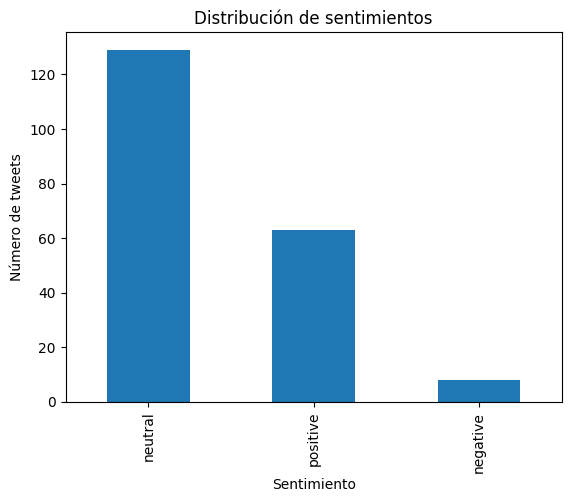

In [14]:
import matplotlib.pyplot as plt

sentiment_counts = df_sentiment["sentiment_label"].value_counts()

ax = sentiment_counts.plot(
    kind="bar",
    title="Distribución de sentimientos"
)

ax.set_xlabel("Sentimiento")
ax.set_ylabel("Número de tweets")

plt.show()

### Análisis de sentimiento

El análisis de sentimiento muestra una predominancia de tweets con polaridad **neutral o ligeramente positiva**.

Esto indica que la mayoría de los mensajes no expresan emociones extremas, sino que:
- comparten información
- realizan análisis
- comentan eventos del mercado

Los tweets positivos suelen estar asociados a expectativas de subida o éxito de inversión, mientras que los neutros reflejan información objetiva o narrativa.

In [15]:
df_parsing = extractor.parse_documents()

df_parsing[[
    "text",
    "subject",
    "verb",
    "object",
    "num_nouns",
    "num_verbs",
    "num_adjectives",
    "num_adverbs",
    "verb_frequency"
]].head()

,text,subject,verb,object,num_nouns,num_verbs,num_adjectives,num_adverbs,verb_frequency
0,"Bitcoin is now in the $78,000–$82,000 resistan...",structure,None,late,18,6,6,7,"{'think': 1, 'flip': 1, 'dump': 1, 'predict': ..."
1,Bitcoin just entered the most dangerous phase ...,call,entered,2026,19,10,11,11,"{'enter': 1, 'think': 1, 's': 1, 'trap': 1, 's..."
2,🚨 BITCOIN IS BOUNCING OFF TRENDLINE SUPPORT!!\...,that,bouncing,mistake,28,16,13,12,"{'bounce': 1, 'happen': 1, 'liquidate': 1, 'lo..."
3,$BTC i am genuinely surprised watching scared...,this,coming,lows,18,14,3,5,"{'watch': 1, 'suppose': 1, 'go': 2, 'blast': 1..."
4,🚨 BITCOIN IS NOW OVERSOLD WHILE GOLD LOOKS EXT...,money,oversold,move,9,6,4,3,"{'oversell': 1, 'look': 1, 'start': 1, 'leave'..."


In [16]:
from spacy import displacy
import spacy

nlp = spacy.load("en_core_web_sm")

sample_text = extractor.data["cleaned_text"].dropna().iloc[0]
doc = nlp(sample_text)

displacy.render(doc, style="dep", jupyter=True)

In [17]:
summary = extractor.parse_and_summarize(summary_ratio=0.1)
summary

'it here first turn notifications on most people will follow me too late bitcoin is still in the bear cycle weve seen this before and btc is about to do it again over the next few weeks 76k 71k 48k 55k 42k next targets 71k in days 42k in june i called the recent dump to 76k i called the 126k top in october 2025 and even 15k bottom in november 2022 if you missed those calls dont worry ill call the next one too follow now ill update you as this dump plays out warning bad news for xrp and sol holders goldman sachs sold all xrp and sol positions the two biggest banks are betting only on bitcoin and ethereum look at the chart the identical move is not a coincidence if youre holding you need to know this blackrock keeps scaling ethereum exposure bitcoin etfs remain dominant sold all sol etf sold all xrp etf kept bitcoin exposure kept ethereum infrastructure plays the two most powerful financial giants in america are now aligned on the same trade bitcoin ethereum this is not just a market sig

### Análisis de parsing sintáctico

En esta sección se aplica **spaCy** para analizar la estructura gramatical de los tweets procesados. El objetivo es ir más allá del contenido textual y observar cómo se organizan internamente las frases.

Para cada tweet se extraen diferentes elementos lingüísticos:

- **subject**: posible sujeto principal de la oración.
- **verb**: verbo principal detectado.
- **object**: posible objeto directo o complemento asociado.
- **num_nouns**: número de sustantivos y nombres propios.
- **num_verbs**: número de verbos.
- **num_adjectives**: número de adjetivos.
- **num_adverbs**: número de adverbios.
- **verb_frequency**: frecuencia de los verbos detectados en cada texto.

Además, se genera un árbol sintáctico mediante `displacy`, que permite visualizar las relaciones de dependencia entre las palabras. En este árbol se puede observar qué palabras actúan como sujeto, verbo, objeto o modificadores dentro de la oración.

Este análisis resulta útil porque permite comprender la estructura lingüística de los tweets y detectar patrones gramaticales frecuentes dentro del corpus. También sirve como paso previo para tareas más avanzadas de NLP, como extracción de relaciones, resumen automático o análisis semántico.

### Resumen extractivo del corpus

El resumen generado recoge los principales temas del conjunto de tweets:

- discusiones sobre el comportamiento del precio de Bitcoin (ciclos, máximos y mínimos)
- noticias relevantes del sector cripto (fraudes, exchanges, pérdidas económicas)
- comparaciones con otros activos financieros (oro, plata, Ethereum)
- opiniones sobre inversión y predicciones futuras

El método extractivo selecciona las oraciones más representativas sin generar texto nuevo, lo que garantiza fidelidad al contenido original.

In [18]:
extractor.export_all_results()

Tópico #0: ['die', 'xrp', 'etf', 'million', 'und']
Tópico #1: ['btc', 'years', 'coming', 'day', 'biggest']
Tópico #2: ['btc', 'price', 'crypto', 'market', 'per']
Tópico #3: ['every', 'btc', 'money', 'move', 'right']

Coherencia: 0.39470386757025006
Perplexity: 766.0180266060883


## 5) Análisis de redes de interacción

In [27]:
interaction_graph = extractor.build_interaction_graph()

print(f"Nodos: {interaction_graph.number_of_nodes()}")
print(f"Aristas: {interaction_graph.number_of_edges()}")

Nodos: 159
Aristas: 27


#### Cálculo de métricas de red

In [28]:
network_results = extractor.analyze_network()

network_results["metrics"].head(10)

,user,degree,in_degree,out_degree,degree_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality
23,MilkRoad,4,0,4,0.025316,0.000000,0.025316,0.000000
31,natbrunell,3,0,3,0.018987,0.000000,0.018987,0.000000
41,saylor,3,1,2,0.018987,0.006329,0.012658,0.000081
75,hollandgold,2,0,2,0.012658,0.000000,0.012658,0.000000
134,KevinWSHPod,2,0,2,0.012658,0.000000,0.012658,0.000000
123,op_catlayer,2,0,2,0.012658,0.000000,0.012658,0.000000
54,Grok,2,2,0,0.012658,0.012658,0.000000,0.000000
112,MARAFoundation_,2,0,2,0.012658,0.000000,0.012658,0.000000
144,Solpok21,2,0,2,0.012658,0.000000,0.012658,0.000000
76,GoedWeerGeniete,1,1,0,0.006329,0.006329,0.000000,0.000000


#### Resumen de resultados y detección de comunidades

In [31]:
network_results["summary"]

{'num_nodes': 159,
 'num_edges': 27,
 'density': 0.0010747551946501074,
 'num_communities': 132,
 'top_3_central_users':           user  degree  in_degree  out_degree  degree_centrality  \
 23    MilkRoad       4          0           4           0.025316   
 31  natbrunell       3          0           3           0.018987   
 41      saylor       3          1           2           0.018987   
 
     in_degree_centrality  out_degree_centrality  betweenness_centrality  
 23              0.000000               0.025316                0.000000  
 31              0.000000               0.018987                0.000000  
 41              0.006329               0.012658                0.000081  }

In [30]:
communities = network_results["communities"]

top_communities = sorted(
    communities,
    key=len,
    reverse=True
)[:5]

for i, community in enumerate(top_communities):
    print(f"Comunidad {i+1}:")
    print(list(community)[:10])
    print()

Comunidad 1:
['MattCrosbyPro', 'MilkRoad', 'BitcoinMagPro', 'LgDoucet', 'BitcoinJesusETH']

Comunidad 2:
['saylor', 'TheBonnieChang', 'davidlin_TV', 'KevinWSHPod', 'Strategy']

Comunidad 3:
['elonmusk', 'ctindale', 'LukeGromen', 'natbrunell']

Comunidad 4:
['DrWhaleReal', 'Grok', 'TheBTCTherapist']

Comunidad 5:
['hollandgold', 'GoedWeerGeniete', 'jsblokland']



### Visualización de la red de interacción

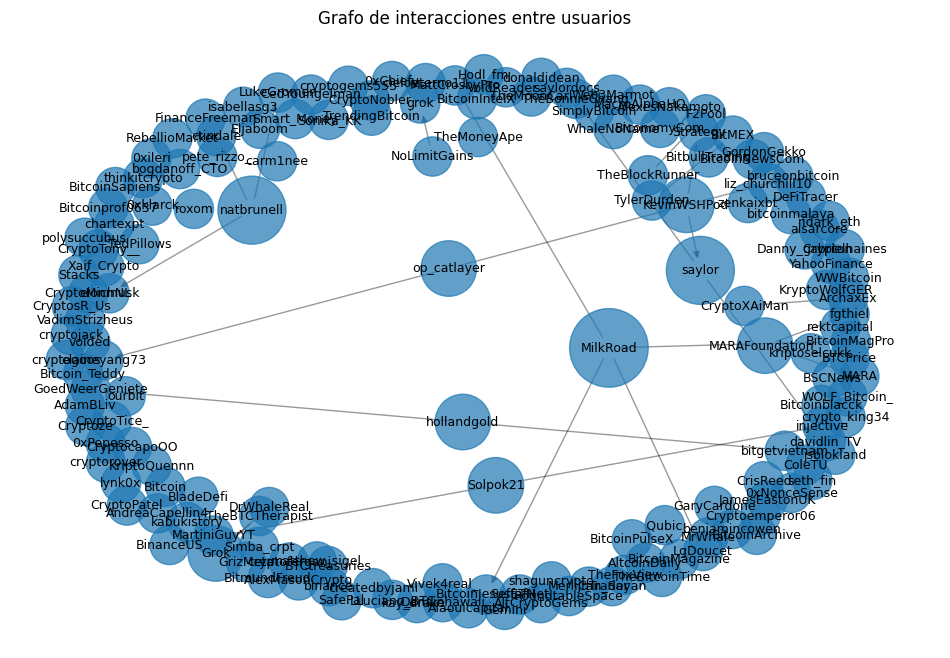

In [22]:
extractor.visualize_network()

### Visualización de comunidades

Además del grafo completo, se han visualizado las comunidades más grandes detectadas en la red.

Cada comunidad representa un subconjunto de usuarios conectados entre sí mediante menciones. Esto permite observar grupos locales de interacción que pueden corresponder a conversaciones, cuentas influyentes o pequeños clusters temáticos dentro del corpus.

La visualización por comunidades facilita el análisis porque el grafo completo puede ser difícil de interpretar cuando contiene muchos nodos. Al separar los subgrafos, es más sencillo identificar qué usuarios actúan como nodos centrales dentro de cada grupo.

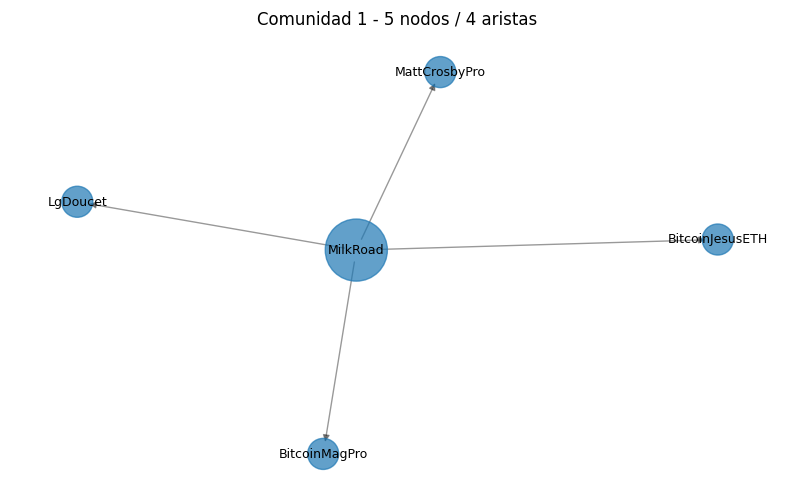

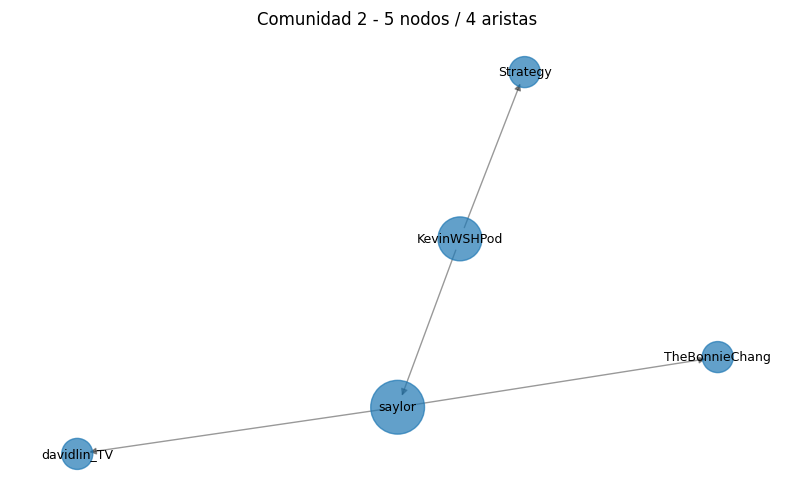

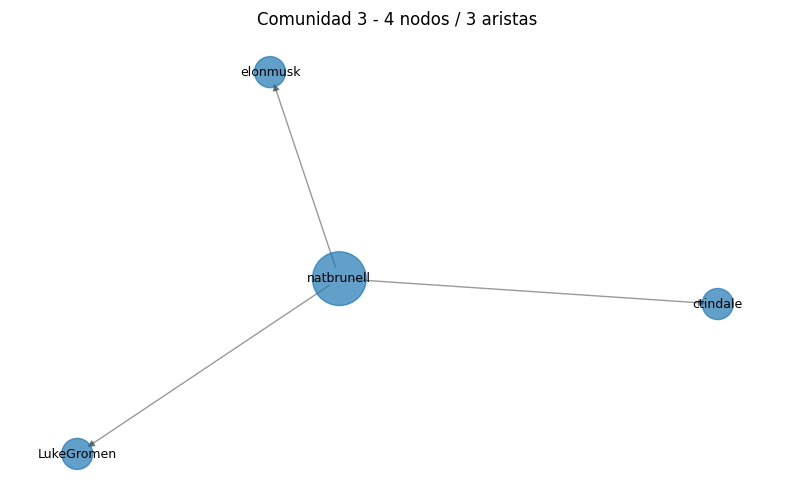

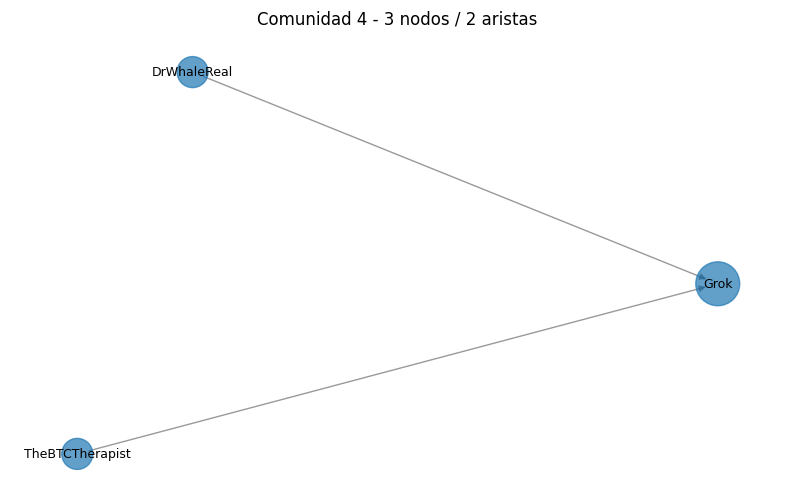

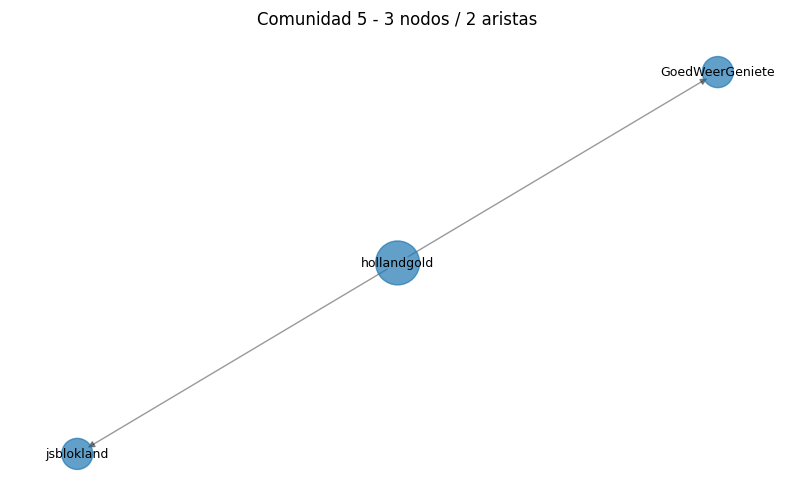

In [32]:
import matplotlib.pyplot as plt
import networkx as nx

graph = network_results["graph"]
communities = network_results["communities"]

top_communities = sorted(
    communities,
    key=len,
    reverse=True
)[:5]

for i, community in enumerate(top_communities, start=1):
    subgraph = graph.subgraph(community)

    plt.figure(figsize=(10, 6))

    pos = nx.spring_layout(subgraph, seed=42)

    node_sizes = [
        max(500 * subgraph.degree(node), 500)
        for node in subgraph.nodes()
    ]

    nx.draw_networkx_nodes(
        subgraph,
        pos,
        node_size=node_sizes,
        alpha=0.7
    )

    nx.draw_networkx_edges(
        subgraph,
        pos,
        arrows=True,
        alpha=0.4
    )

    nx.draw_networkx_labels(
        subgraph,
        pos,
        font_size=9
    )

    plt.title(f"Comunidad {i} - {subgraph.number_of_nodes()} nodos / {subgraph.number_of_edges()} aristas")
    plt.axis("off")
    plt.show()